# Calibration Coefficient Methodology: Per-Model vs. Mean-of-Models

**Question:** to correct the pipeline's known over-scoring bias (see
`11_adjudication_readiness_analysis.md`), should the correction be fit **per model**
(before the models are averaged) or on the **mean-of-models** ensemble score (after
averaging)? And which of two coefficient-fitting methodologies works better?

Both correction methodologies here fit purely on cached scores + expert labels — no
LLM calls — so either can be refit in seconds whenever the expert calibration set
changes. This notebook compares them on held-out data via grouped cross-validation.

- Raw per-model scores: `merged_ra_affinities.csv` (run `20260726_134607_1`, pre-adjudication)
- Expert labels: `calibration_abstract_question_affinities.csv`, Mark and Charlie expert sets
  (kept separate throughout — never pooled, per notebook 11's convention)


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 120


In [ ]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
import importlib
import sys

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

affinity_metrics = importlib.import_module("src.analysis.affinity_metrics")

pred_root = repo_root / "data" / "results" / "affinity_benchmark"
expert_root = repo_root / "data" / "processed" / "affinity_calibration"

pred_run_dir_name = "20260726_134607_1"  # 4-example few-shot benchmark run

expert_run_dir_names = [
    "20260728_abstracts_evaluation_template_mark_om_v1",
    "20260728_abstracts_evaluation_template_charlie_s_v1",
]
expert_labels = {expert_run_dir_names[0]: "Mark", expert_run_dir_names[1]: "Charlie"}

LABEL_ORDER = ["Low", "Moderate", "High"]
LABEL_TO_NUM = {"Low": 0, "Moderate": 1, "High": 2}
APPROACH_ORDER = [
    "baseline_uncalibrated",
    "mean_additive",
    "mean_affine",
    "per_model_additive",
    "per_model_affine",
]
N_FOLDS = 5


def normalize_level(score):
    if pd.isna(score):
        return np.nan
    if 0 <= score < 40:
        return "Low"
    if 40 <= score < 80:
        return "Moderate"
    if 80 <= score <= 120:
        return "High"
    return np.nan


## 1. Load raw per-model scores and the ensemble mean

Raw per-model affinity scores come from `merged_ra_affinities.csv` (one row per
abstract x RA question x model, pre-adjudication). Both the pipeline scores and the
expert scale share the same 0-120 range and Low/Moderate/High thresholds.

In [ ]:
merged_path = pred_root / pred_run_dir_name / "merged_ra_affinities.csv"
raw_long = pd.read_csv(merged_path)[["Abstract_Index", "RA2025_ID", "Model_Slug", "LLM_Affinity"]]
raw_long = raw_long.dropna(subset=["LLM_Affinity"])

ensemble_mean_df = (
    raw_long.groupby(["Abstract_Index", "RA2025_ID"], as_index=False)["LLM_Affinity"]
    .mean()
    .rename(columns={"LLM_Affinity": "Ensemble_Mean_Affinity"})
)

print("Raw per-model rows:", len(raw_long))
print("Models:", sorted(raw_long["Model_Slug"].unique()))
print("Ensemble pairs:", len(ensemble_mean_df))
raw_long.head()


Raw per-model rows: 20091
Models: ['gemini-3.1-flash-lite', 'gemma4-31b-cloud', 'gpt-5.4-mini', 'mistral-large-3-675b-cloud']
Ensemble pairs: 5040


,Abstract_Index,RA2025_ID,Model_Slug,LLM_Affinity
0,10.1109/TPWRS.2023.3292799,13,gemini-3.1-flash-lite,95.0
1,10.1109/TPWRS.2023.3292799,44,gemini-3.1-flash-lite,40.0
2,10.1109/TPWRS.2023.3292799,35,gemini-3.1-flash-lite,60.0
3,10.1109/TPWRS.2023.3292799,45,gemini-3.1-flash-lite,20.0
4,10.1109/TPWRS.2023.3292799,33,gemini-3.1-flash-lite,50.0


## 2. Two calibration methodologies

1. **Additive bias** — shift by the mean signed error: `corrected = raw - mean(raw - expert)`.
   One coefficient, matches the bias already reported in notebook 11.
2. **Affine (OLS) regression** — fit `expert ~ intercept + slope * raw` by least squares,
   then `corrected = intercept + slope * raw`. Two coefficients; corrects scale as well as offset.

Corrected scores are clipped to `[0, 120]`, matching the production score-clamping behavior
in `LLMBase`. Each methodology is applied two ways:

- **Per-model**: fit separate coefficients per `Model_Slug` on that model's raw scores,
  correct each model's score, then average the *corrected* scores across models.
- **Mean-of-models**: average raw scores across models first (`Ensemble_Mean_Affinity`),
  then fit and apply a single correction to that mean.

In [ ]:
def fit_additive_bias(raw_train, expert_train):
    return (float(np.mean(raw_train - expert_train)),)


def apply_additive_bias(raw, bias):
    return np.clip(raw - bias, 0, 120)


def fit_affine(raw_train, expert_train):
    slope, intercept = np.polyfit(raw_train, expert_train, deg=1)
    return float(slope), float(intercept)


def apply_affine(raw, slope, intercept):
    return np.clip(slope * raw + intercept, 0, 120)


def evaluate_predictions(expert_score, pred_score):
    expert_num = expert_score.apply(normalize_level).map(LABEL_TO_NUM)
    pred_num = pred_score.apply(normalize_level).map(LABEL_TO_NUM)
    keep = expert_num.notna() & pred_num.notna()
    overall = affinity_metrics.build_affinity_overall_metrics(
        expert_num[keep].astype(int), pred_num[keep].astype(int)
    )
    return dict(zip(overall["Metric"], overall["Value"])), int(keep.sum())


def mean_corrected_predictions(mean_train, mean_test, fit_fn, apply_fn):
    coeffs = fit_fn(mean_train["Ensemble_Mean_Affinity"], mean_train["Evaluator_Affinity"])
    corrected = apply_fn(mean_test["Ensemble_Mean_Affinity"], *coeffs)
    return mean_test["Evaluator_Affinity"], corrected


def per_model_corrected_predictions(model_train, model_test, fit_fn, apply_fn):
    model_test = model_test.copy()
    model_test["corrected"] = np.nan
    for model_slug, train_rows in model_train.groupby("Model_Slug"):
        coeffs = fit_fn(train_rows["LLM_Affinity"], train_rows["Evaluator_Affinity"])
        rows = model_test["Model_Slug"] == model_slug
        model_test.loc[rows, "corrected"] = apply_fn(model_test.loc[rows, "LLM_Affinity"], *coeffs)
    pair_corrected = model_test.groupby(["Abstract_Index", "RA2025_ID"]).agg(
        corrected=("corrected", "mean"), Evaluator_Affinity=("Evaluator_Affinity", "first")
    )
    return pair_corrected["Evaluator_Affinity"], pair_corrected["corrected"]


## 3. Cross-validated comparison

Both approaches and both methodologies are evaluated on the same `GroupKFold` (grouped by
`Abstract_Index`, so no abstract leaks between train and test) for a fair, held-out
comparison — a coefficient fit on the same rows it's scored on would overstate how well it
generalizes to a new expert batch.

In [ ]:
results = []

for expert_dir_name in expert_run_dir_names:
    expert_path = expert_root / expert_dir_name / "calibration_abstract_question_affinities.csv"
    expert_df = pd.read_csv(expert_path)[
        ["Abstract_Index", "RA2025_ID", "Evaluator_Affinity", "Evaluator_Affinity_Level"]
    ]

    per_model_df = raw_long.merge(expert_df, on=["Abstract_Index", "RA2025_ID"], how="inner")
    mean_df = ensemble_mean_df.merge(expert_df, on=["Abstract_Index", "RA2025_ID"], how="inner")

    pair_keys = mean_df[["Abstract_Index", "RA2025_ID"]].reset_index(drop=True)
    fold_of_pair = pd.Series(index=pair_keys.index, dtype=int)
    splitter = GroupKFold(n_splits=N_FOLDS).split(pair_keys, groups=pair_keys["Abstract_Index"])
    for fold, (_, test_idx) in enumerate(splitter):
        fold_of_pair.iloc[test_idx] = fold
    pair_keys["fold"] = fold_of_pair

    mean_df = mean_df.merge(pair_keys, on=["Abstract_Index", "RA2025_ID"], how="left")
    per_model_df = per_model_df.merge(pair_keys, on=["Abstract_Index", "RA2025_ID"], how="left")

    for fold in range(N_FOLDS):
        mean_train = mean_df[mean_df["fold"] != fold]
        mean_test = mean_df[mean_df["fold"] == fold]
        model_train = per_model_df[per_model_df["fold"] != fold]
        model_test = per_model_df[per_model_df["fold"] == fold]

        approach_predictions = {
            "baseline_uncalibrated": (mean_test["Evaluator_Affinity"], mean_test["Ensemble_Mean_Affinity"]),
            "mean_additive": mean_corrected_predictions(mean_train, mean_test, fit_additive_bias, apply_additive_bias),
            "mean_affine": mean_corrected_predictions(mean_train, mean_test, fit_affine, apply_affine),
            "per_model_additive": per_model_corrected_predictions(model_train, model_test, fit_additive_bias, apply_additive_bias),
            "per_model_affine": per_model_corrected_predictions(model_train, model_test, fit_affine, apply_affine),
        }

        for approach, (expert_actual, pred_score) in approach_predictions.items():
            metrics, n = evaluate_predictions(expert_actual, pred_score)
            results.append({"expert_set": expert_dir_name, "approach": approach, "fold": fold, "n": n, **metrics})

results_df = pd.DataFrame(results)
results_df["approach"] = pd.Categorical(results_df["approach"], categories=APPROACH_ORDER, ordered=True)
results_df.head()


,expert_set,approach,fold,n,Accuracy,Quadratic Weighted Kappa,Mean Signed Error
0,20260728_abstracts_evaluation_template_mark_om_v1,baseline_uncalibrated,0,121,0.669421,0.411633,0.033058
1,20260728_abstracts_evaluation_template_mark_om_v1,mean_additive,0,121,0.710744,0.327698,-0.206612
2,20260728_abstracts_evaluation_template_mark_om_v1,mean_affine,0,121,0.702479,0.194129,-0.314050
3,20260728_abstracts_evaluation_template_mark_om_v1,per_model_additive,0,121,0.710744,0.327698,-0.206612
4,20260728_abstracts_evaluation_template_mark_om_v1,per_model_affine,0,121,0.685950,0.110627,-0.338843


## 4. Held-out metrics by approach (mean +/- std across folds)

In [ ]:
summary_df = (
    results_df.groupby(["expert_set", "approach"], observed=True)[
        ["Accuracy", "Quadratic Weighted Kappa", "Mean Signed Error"]
    ]
    .agg(["mean", "std"])
    .round(4)
)
summary_df


Accuracy  \
                                                                             mean   
expert_set                                         approach                         
20260728_abstracts_evaluation_template_charlie_... baseline_uncalibrated   0.7269   
                                                   mean_additive           0.8144   
                                                   mean_affine             0.8559   
                                                   per_model_additive      0.8144   
                                                   per_model_affine        0.8545   
20260728_abstracts_evaluation_template_mark_om_v1  baseline_uncalibrated   0.6194   
                                                   mean_additive           0.7208   
                                                   mean_affine             0.7509   
                                                   per_model_additive      0.7208   
                                                   per_model_affine        0.7642   

                                                                                  \
                                                                             std   
expert_set                                         approach                        
20260728_abstracts_evaluation_template_charlie_... baseline_uncalibrated  0.0635   
                                                   mean_additive          0.0260   
                                                   mean_affine            0.0253   
                                                   per_model_additive     0.0260   
                                                   per_model_affine       0.0241   
20260728_abstracts_evaluation_template_mark_om_v1  baseline_uncalibrated  0.0828   
                                                   mean_additive          0.0506   
                                                   mean_affine            0.0334   
                                                   per_model_additive     0.0506   
                                                   per_model_affine       0.0458   

                                                                         Quadratic Weighted Kappa  \
                                                                                             mean   
expert_set                                         approach                                         
20260728_abstracts_evaluation_template_charlie_... baseline_uncalibrated                   0.3607   
                                                   mean_additive                           0.3666   
                                                   mean_affine                             0.0176   
                                                   per_model_additive                      0.3666   
                                                   per_model_affine                        0.0000   
20260728_abstracts_evaluation_template_mark_om_v1  baseline_uncalibrated                   0.4548   
                                                   mean_additive                           0.4282   
                                                   mean_affine                             0.3804   
                                                   per_model_additive                      0.4282   
                                                   per_model_affine                        0.3722   

                                                                                  \
                                                                             std   
expert_set                                         approach                        
20260728_abstracts_evaluation_template_charlie_... baseline_uncalibrated  0.0714   
                                                   mean_additive          0.0751   
                                                   mean_affine            0.0394   
                                                   per_m

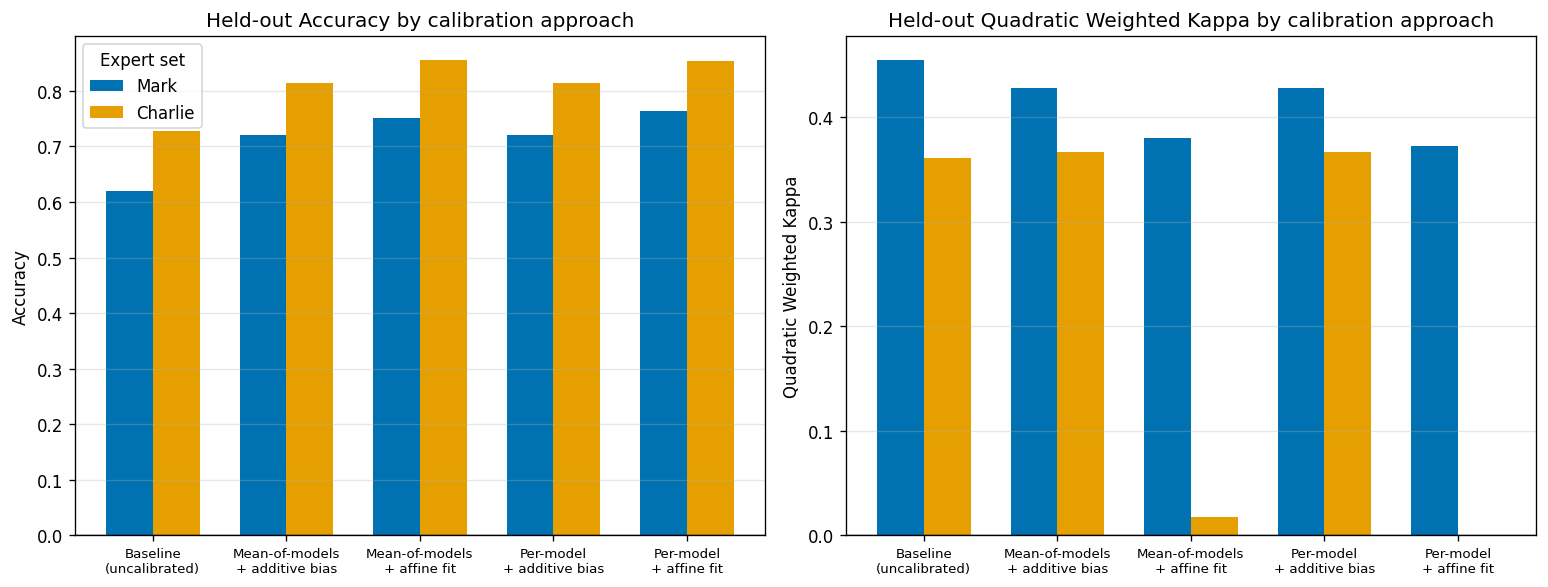

In [ ]:
approach_display = {
    "baseline_uncalibrated": "Baseline\n(uncalibrated)",
    "mean_additive": "Mean-of-models\n+ additive bias",
    "mean_affine": "Mean-of-models\n+ affine fit",
    "per_model_additive": "Per-model\n+ additive bias",
    "per_model_affine": "Per-model\n+ affine fit",
}
expert_colors = {expert_run_dir_names[0]: "#0072B2", expert_run_dir_names[1]: "#E69F00"}

cv_mean_df = (
    results_df.groupby(["expert_set", "approach"], observed=True)[["Accuracy", "Quadratic Weighted Kappa"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_width = 0.35
x = np.arange(len(APPROACH_ORDER))

for ax, metric in zip(axes, ["Accuracy", "Quadratic Weighted Kappa"]):
    for i, expert_dir_name in enumerate(expert_run_dir_names):
        subset = (
            cv_mean_df[cv_mean_df["expert_set"] == expert_dir_name]
            .set_index("approach")
            .reindex(APPROACH_ORDER)
        )
        ax.bar(
            x + (i - 0.5) * bar_width,
            subset[metric],
            width=bar_width,
            color=expert_colors[expert_dir_name],
            label=expert_labels[expert_dir_name],
        )
    ax.set_xticks(x)
    ax.set_xticklabels([approach_display[a] for a in APPROACH_ORDER], fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f"Held-out {metric} by calibration approach")
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.8)

axes[0].legend(title="Expert set")
plt.tight_layout()
plt.show()


## 5. Fitted coefficients on full data (interpretability)

Fit on all available pairs (no held-out split) to see how much the per-model coefficients
actually differ from each other and from the single mean-of-models coefficient — if they're
all similar, the extra per-model complexity isn't buying anything; if they diverge, per-model
correction should show up as a real accuracy/kappa advantage in section 4.

In [ ]:
coefficient_rows = []
for expert_dir_name in expert_run_dir_names:
    expert_path = expert_root / expert_dir_name / "calibration_abstract_question_affinities.csv"
    expert_df = pd.read_csv(expert_path)[
        ["Abstract_Index", "RA2025_ID", "Evaluator_Affinity", "Evaluator_Affinity_Level"]
    ]
    per_model_df = raw_long.merge(expert_df, on=["Abstract_Index", "RA2025_ID"], how="inner")
    mean_df = ensemble_mean_df.merge(expert_df, on=["Abstract_Index", "RA2025_ID"], how="inner")

    bias = fit_additive_bias(mean_df["Ensemble_Mean_Affinity"], mean_df["Evaluator_Affinity"])[0]
    slope, intercept = fit_affine(mean_df["Ensemble_Mean_Affinity"], mean_df["Evaluator_Affinity"])
    coefficient_rows.append({
        "expert_set": expert_labels[expert_dir_name], "model": "mean_of_models", "n": len(mean_df),
        "additive_bias": bias, "affine_slope": slope, "affine_intercept": intercept,
    })

    for model_slug, group in per_model_df.groupby("Model_Slug"):
        bias = fit_additive_bias(group["LLM_Affinity"], group["Evaluator_Affinity"])[0]
        slope, intercept = fit_affine(group["LLM_Affinity"], group["Evaluator_Affinity"])
        coefficient_rows.append({
            "expert_set": expert_labels[expert_dir_name], "model": model_slug, "n": len(group),
            "additive_bias": bias, "affine_slope": slope, "affine_intercept": intercept,
        })

coefficients_df = pd.DataFrame(coefficient_rows).round(4)
coefficients_df


,expert_set,model,n,additive_bias,affine_slope,affine_intercept
0,Mark,mean_of_models,602,17.6177,0.5228,2.6782
1,Mark,gemini-3.1-flash-lite,602,25.9136,0.5246,-1.7503
2,Mark,gemma4-31b-cloud,602,15.6312,0.4418,7.0024
3,Mark,gpt-5.4-mini,602,8.1595,0.3522,13.2661
4,Mark,mistral-large-3-675b-cloud,595,20.6218,0.4987,2.1950
5,Charlie,mean_of_models,722,16.6588,0.3338,5.9734
6,Charlie,gemini-3.1-flash-lite,721,25.4646,0.3012,4.4339
7,Charlie,gemma4-31b-cloud,722,13.5665,0.2901,8.3538
8,Charlie,gpt-5.4-mini,722,7.6011,0.2484,11.1255
9,Charlie,mistral-large-3-675b-cloud,720,20.1042,0.3030,5.9898


## 6. Conclusion and recommendation

**Use the mean-of-models + additive correction. Don't use the affine (regression) correction.**

**Why not affine:** it gets a higher accuracy score, but that number is misleading. Checking
the actual corrected scores for the Charlie expert set shows the fix squeezes almost every
score down into the "Low" bucket (719 out of 722 pairs), and none ever reach "High" — even a
raw score of 120 only corrects down to about 48. The model basically stops making real
predictions and just guesses "Low" most of the time. Since "Low" is also the most common true
answer, accuracy looks fine by accident, but the Quadratic Weighted Kappa score (which checks
whether predictions actually distinguish Low/Moderate/High) drops to 0 for this expert set —
confirming the predictions collapsed to one class.

**Why mean-of-models, not per-model:** fitting a correction per model and then averaging gives
the exact same result as averaging the models first and fitting one correction — down to 4
decimal places, in every fold, for both experts. This is true even though the individual
models' biases are quite different (gemini's is 3x gpt-5.4-mini's). So fitting per model adds
extra coefficients to maintain for no real benefit — one correction number is enough.

**Bottom line:** mean-of-models + additive correction removes almost all of the scoring bias
(mean error goes from about +0.25 to roughly 0), raises accuracy by 10-14 points, and keeps
the Low/Moderate/High distinctions intact — without the collapse the affine method causes.

**Worth checking later:**
- The affine method's slope (0.25-0.52 across models) shows the raw LLM scores are more
  spread out than the expert's scores. That's a real pattern worth understanding, even though
  correcting for it this way backfires.
- Any future scale-correction attempt should check the predicted Low/Moderate/High mix before
  trusting it, so a collapse like this gets caught automatically instead of only showing up as
  a suspiciously good accuracy number.
